In [1]:
import os
import numpy as np
from sklearn.model_selection import train_test_split
import random
import librosa
import soundfile as sf
import shutil
import matplotlib.pyplot as plt
from collections import defaultdict

data_dir = "X:/Projects/ML/Assignment-1/Q2/Dataset"
output_dir = "X:/Projects/ML/Assignment-1/Q2/Model_split"
augmented_dir = "X:/Projects/ML/Assignment-1/Q2/Augmented"

In [2]:
def split_data(data_dir, train_ratio=0.8, val_ratio=0.1):
    train_files, train_labels = [], []
    val_files, val_labels = [], []
    test_files, test_labels = [], []

    for label in os.listdir(data_dir):
        label_path = os.path.join(data_dir, label)
        if os.path.isdir(label_path):
            class_files = [
                os.path.join(label_path, file) 
                for file in os.listdir(label_path) if file.endswith(".wav")
            ]
            class_labels = [label] * len(class_files)
            
            if len(class_files) < 10:
                train_class, temp_class, train_label, temp_label = train_test_split(class_files, class_labels, test_size=(1 - train_ratio))
                val_class, test_class, val_label, test_label = train_test_split(temp_class, temp_label, test_size=0.5)
                
            else:
                train_class, temp_class, train_label, temp_label = train_test_split(class_files, class_labels, test_size=(1 - train_ratio), stratify=class_labels)
                val_ratio_adjusted = val_ratio / (1 - train_ratio)
                val_class, test_class, val_label, test_label = train_test_split(temp_class, temp_label, test_size=(1 - val_ratio_adjusted), stratify=temp_label)

            train_files.extend(train_class)
            train_labels.extend(train_label)
            val_files.extend(val_class)
            val_labels.extend(val_label)
            test_files.extend(test_class)
            test_labels.extend(test_label)

    return (train_files, train_labels), (val_files, val_labels), (test_files, test_labels)

def split_directories(output_dir, split_data):
    for split_name, (files, labels) in split_data.items():
        split_dir = os.path.join(output_dir, split_name)
        os.makedirs(split_dir, exist_ok=True)
        for file, label in zip(files, labels):
            label_dir = os.path.join(split_dir, label)
            os.makedirs(label_dir, exist_ok=True)
            shutil.copy(file, label_dir)

(train_files, train_labels), (val_files, val_labels), (test_files, test_labels) = split_data(data_dir)
split_data = {"train": (train_files, train_labels),"val": (val_files, val_labels),"test": (test_files, test_labels),}

print("Creating directories and copying files")
split_directories(output_dir, split_data)
print("Data successfully split into train, val, and test directories.\n")
print(f"Total Files: {len(train_files) + len(val_files) + len(test_files)}")
print(f"Training Files: {len(train_files)}")
print(f"Validation Files: {len(val_files)}")
print(f"Testing Files: {len(test_files)}")

Creating directories and copying files
Data successfully split into train, val, and test directories.

Total Files: 105835
Training Files: 84655
Validation Files: 10580
Testing Files: 10600


In [3]:
def compute_feature(file):
    y, sr = librosa.load(file, sr=None)
    zcr = librosa.feature.zero_crossing_rate(y)[0].mean()

    auto_corr = np.correlate(y, y, mode="full")
    max_auto_corr = auto_corr.max()
    
    return zcr, max_auto_corr

random_files = random.sample(train_files, 5)

print("Computing features for 5 randomly selected training files:\n")
for i, file in enumerate(random_files, 1):
    zcr, max_auto_corr = compute_feature(file)
    print(f"File {i}: {os.path.basename(file)}")
    print(f"  Zero Crossing Rate (ZCR): {zcr:.4f}")
    print(f"  Max Auto-correlation: {max_auto_corr:.4f}\n")

Computing features for 5 randomly selected training files:

File 1: 763188c4_nohash_0.wav
  Zero Crossing Rate (ZCR): 0.1469
  Max Auto-correlation: 116.4270

File 2: 513aeddf_nohash_1.wav
  Zero Crossing Rate (ZCR): 0.0827
  Max Auto-correlation: 32.3813

File 3: 97f4c236_nohash_4.wav
  Zero Crossing Rate (ZCR): 0.0646
  Max Auto-correlation: 173.9473

File 4: a4e8a997_nohash_0.wav
  Zero Crossing Rate (ZCR): 0.0291
  Max Auto-correlation: 36.8240

File 5: 6f2c6f7e_nohash_0.wav
  Zero Crossing Rate (ZCR): 0.2054
  Max Auto-correlation: 43.1917



Generating spectrograms for 5 randomly selected classes:

Class: happy
File: 3d6bee47_nohash_0.wav


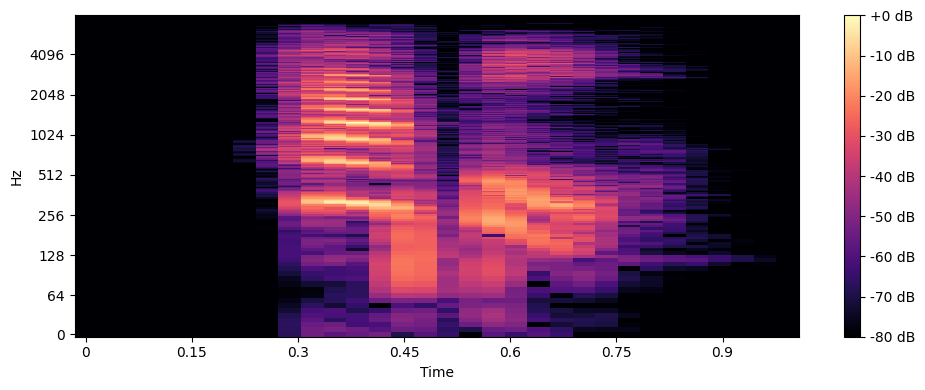

Class: _background_noise_
File: exercise_bike.wav


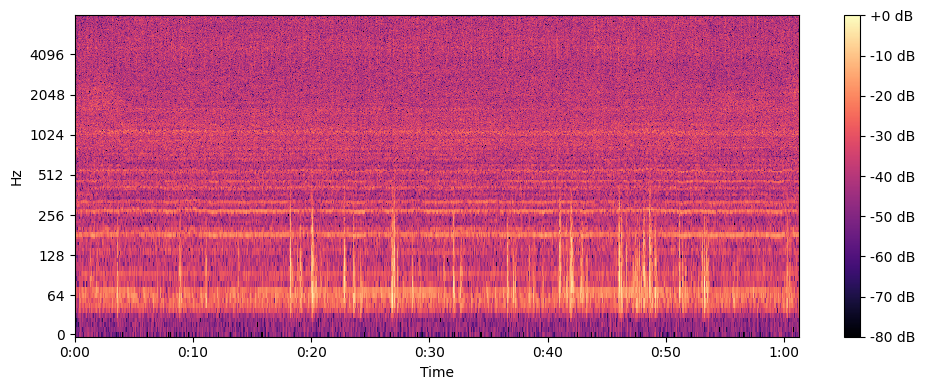

Class: zero
File: e62056e2_nohash_0.wav


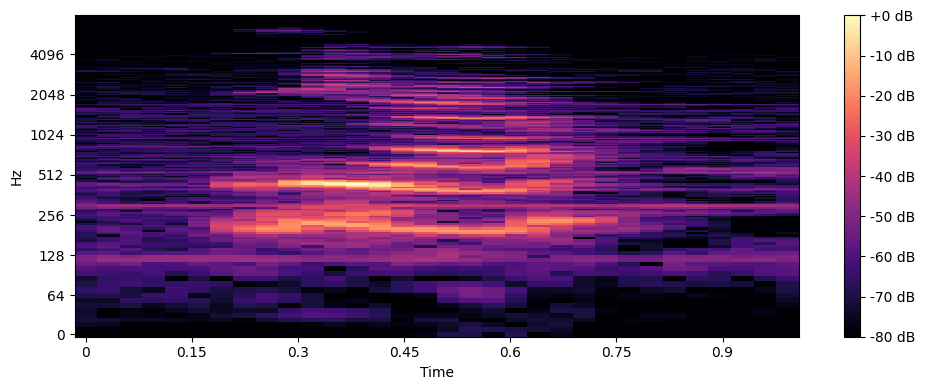

Class: tree
File: db9d52d2_nohash_2.wav


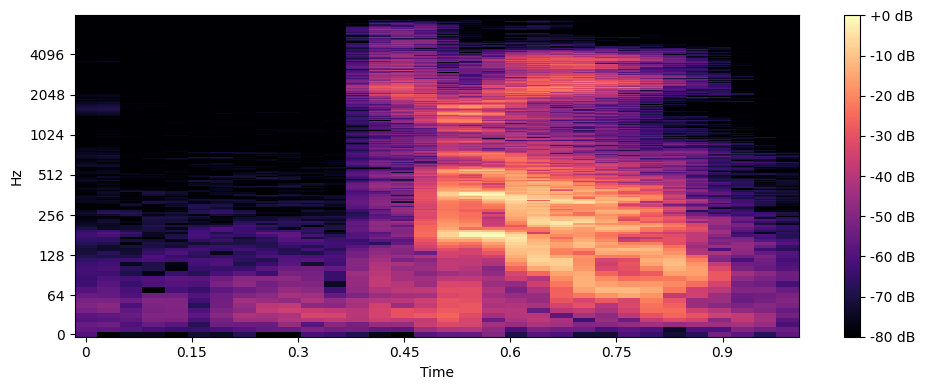

Class: stop
File: f575faf3_nohash_0.wav


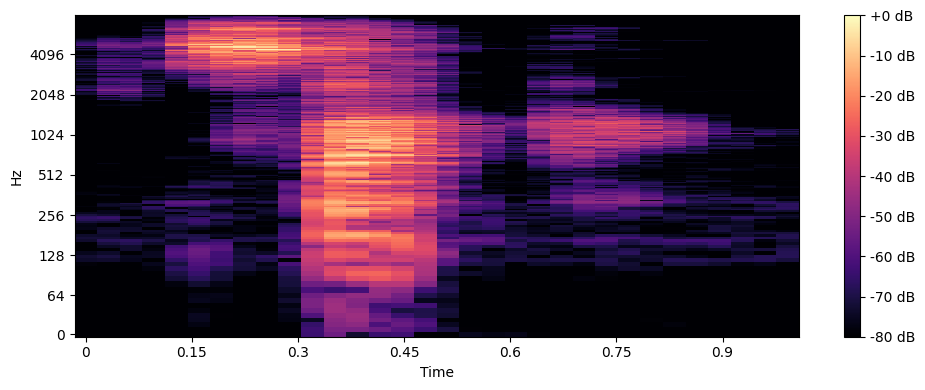

In [4]:
def plot_spectrogram(file):
    y, sr = librosa.load(file, sr=None)
    spectrogram = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max)

    plt.figure(figsize=(10, 4))
    librosa.display.specshow(spectrogram, sr=sr, x_axis='time', y_axis='log')
    plt.colorbar(format='%+2.0f dB')
    plt.tight_layout()
    plt.show()

train_data_class = defaultdict(list)
for file, label in zip(train_files, train_labels):
    train_data_class[label].append(file)
selected_classes = random.sample(list(train_data_class.keys()), 5)

print("Generating spectrograms for 5 randomly selected classes:\n")
for i in selected_classes:
    sample_file = random.choice(train_data_class[i])
    print(f"Class: {i}\nFile: {os.path.basename(sample_file)}")
    plot_spectrogram(sample_file)

In [5]:
def change_pitch(audio, sr, n_steps):
    new_pitch = librosa.effects.pitch_shift(y=audio, sr=sr, n_steps=n_steps)
    return new_pitch

def add_bgnoise(audio, noise_level):
    noise = np.random.normal(0, noise_level, len(audio))
    return audio + noise

def time_stretch(audio, rate):
    stretch_audio = librosa.effects.time_stretch(y=audio, rate=rate)
    return stretch_audio

os.makedirs(augmented_dir, exist_ok=True)
random_files = random.sample(train_files, 5)

print("Applying data augmentation techniques to 5 randomly chosen files:\n")
for i, file in enumerate(random_files, 1):
    y, sr = librosa.load(file, sr=None)

    pitch_audio = change_pitch(y, sr, n_steps=8)
    noisy_audio = add_bgnoise(y, noise_level=0.1)
    stretch_audio = time_stretch(y, rate=0.5)

    sf.write(os.path.join(augmented_dir, f"{i}_original.wav"), y, sr)
    sf.write(os.path.join(augmented_dir, f"{i}_pitch_changed.wav"), pitch_audio, sr)
    sf.write(os.path.join(augmented_dir, f"{i}_noisy.wav"), noisy_audio, sr)
    sf.write(os.path.join(augmented_dir, f"{i}_stretched.wav"), stretch_audio, sr)

    print(f"File {i}: {os.path.basename(file)}")
    print(f"  Original file saved as {i}_original.wav")
    print(f"  Pitch-shifted file saved as {i}_pitch_changed.wav")
    print(f"  Noisy file saved as {i}_noisy.wav")
    print(f"  Time-stretched file saved as {i}_stretched.wav\n")


Applying data augmentation techniques to 5 randomly chosen files:

File 1: ac9dee0e_nohash_2.wav
  Original file saved as 1_original.wav
  Pitch-shifted file saved as 1_pitch_changed.wav
  Noisy file saved as 1_noisy.wav
  Time-stretched file saved as 1_stretched.wav

File 2: 8d4cdc60_nohash_0.wav
  Original file saved as 2_original.wav
  Pitch-shifted file saved as 2_pitch_changed.wav
  Noisy file saved as 2_noisy.wav
  Time-stretched file saved as 2_stretched.wav

File 3: 2dce72b3_nohash_1.wav
  Original file saved as 3_original.wav
  Pitch-shifted file saved as 3_pitch_changed.wav
  Noisy file saved as 3_noisy.wav
  Time-stretched file saved as 3_stretched.wav

File 4: a62f807b_nohash_0.wav
  Original file saved as 4_original.wav
  Pitch-shifted file saved as 4_pitch_changed.wav
  Noisy file saved as 4_noisy.wav
  Time-stretched file saved as 4_stretched.wav

File 5: fdb5155e_nohash_0.wav
  Original file saved as 5_original.wav
  Pitch-shifted file saved as 5_pitch_changed.wav
  Noi